In [2]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
import mlflow, mlflow.sklearn

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.data import get_splits

X_tr, X_te, y_tr, y_te = get_splits()
mlflow.set_tracking_uri(f"sqlite:///{(ROOT / 'mlflow.db').as_posix()}")
champion = mlflow.xgboost.load_model("models:/fraud-champion@champion")

In [3]:
from src.threshold import sweep, expected_cost

proba = champion.predict_proba(X_te)[:, 1]   # fraud probability per transaction
amounts = X_te["Amount"].values              # used for false-negative cost
y_true = y_te.values                         # plain numpy array, avoids pandas quirks

In [12]:
thresholds, costs, best_t = sweep(y_true, proba, amounts)

best_cost = costs.min()
cost_05 = expected_cost(y_true, proba, 0.5, amounts)

print(f"Best threshold : {best_t:.3f}")
print(f"Cost at best   : ₹{best_cost:,.0f}")
print(f"Cost at 0.5    : ₹{cost_05:,.0f}")
print(f"Savings        : ₹{cost_05 - best_cost:,.0f}")

Best threshold : 0.150
Cost at best   : ₹35,200
Cost at 0.5    : ₹38,000
Savings        : ₹2,800


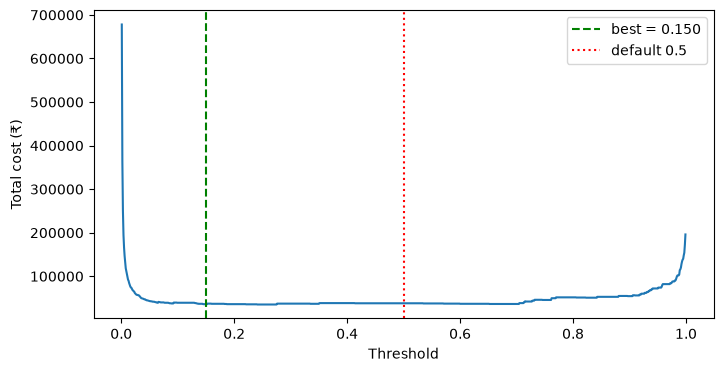

In [14]:
import os
import matplotlib.pyplot as plt

os.makedirs("../reports/figures", exist_ok=True)
plt.figure(figsize=(8, 4))
plt.plot(thresholds, costs)
plt.axvline(best_t, color="green", linestyle="--", label=f"best = {best_t:.3f}")
plt.axvline(0.5, color="red", linestyle=":", label="default 0.5")
plt.xlabel("Threshold"); plt.ylabel("Total cost (₹)"); plt.legend()
os.makedirs(ROOT / "reports" / "figures", exist_ok=True)
plt.savefig(ROOT / "reports" / "figures" / "06_cost_vs_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
## Calibration
from sklearn.calibration import	CalibratedClassifierCV,	calibration_curve
from sklearn.frozen	import FrozenEstimator
from sklearn.model_selection import	train_test_split
from sklearn.metrics import	brier_score_loss

#	Carve	the	calibration	set	out	of	TRAIN,	never	test
X_fit,	X_cal,	y_fit,	y_cal	=	train_test_split(
    X_tr, y_tr,	test_size=0.25,	stratify=y_tr, random_state=42
    )

champion.fit(X_fit,	y_fit)
calibrated = CalibratedClassifierCV(FrozenEstimator(champion),	method="isotonic").fit(X_cal, y_cal)

p_raw =	champion.predict_proba(X_te)[:,	1]
p_cal =	calibrated.predict_proba(X_te)[:,	1]

print(f"Brier raw :	{brier_score_loss(y_te,	p_raw):.6f}")
print(f"Brier cal :	{brier_score_loss(y_te,	p_cal):.6f}")

frac_pos, mean_pred	= calibration_curve(y_te, p_cal, n_bins=10,	strategy="quantile")

Brier raw :	0.000363
Brier cal :	0.000412


In [9]:
#above the brier loss score loss increase meaning isotonic requires larger data given test set has only 90 frauds that makes it harder to learn.
probs = {"Raw": p_raw}
for method in ("isotonic", "sigmoid"):
    cv_cal = CalibratedClassifierCV(champion, method=method, cv=5).fit(X_tr, y_tr)
    probs[f"{method}, cv=5"] = cv_cal.predict_proba(X_te)[:, 1]
    fr_cal = CalibratedClassifierCV(FrozenEstimator(champion), method=method).fit(X_cal, y_cal)
    probs[f"{method}, frozen"] = fr_cal.predict_proba(X_te)[:, 1]

for name, p in probs.items():
    print(f"{name:18s} Brier={brier_score_loss(y_te, p):.6f}")

Raw                Brier=0.000363
isotonic, cv=5     Brier=0.000366
isotonic, frozen   Brier=0.000412
sigmoid, cv=5      Brier=0.000373
sigmoid, frozen    Brier=0.000378


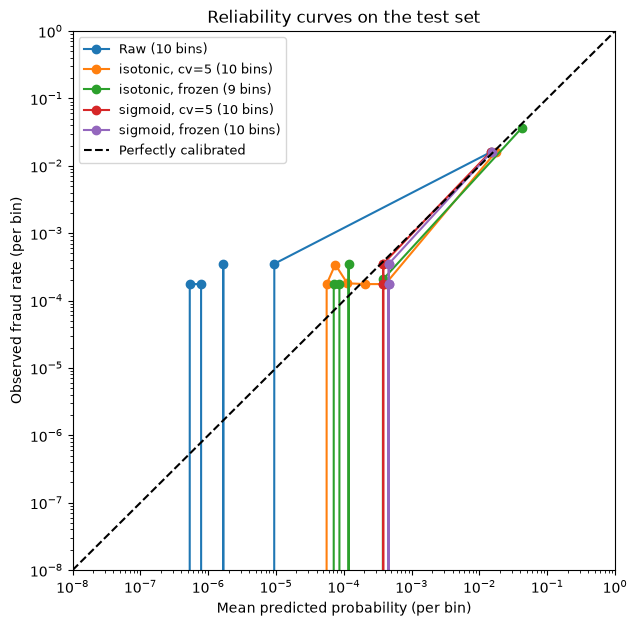

In [15]:
# Reliability curves: raw vs calibrated, all scored on the test set
# Requires the probs dict from the Brier cell above.
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path
from pathlib import Path
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 7))

for name, p in probs.items():
    frac_pos, mean_pred = calibration_curve(y_te, p, n_bins=10, strategy="quantile")
    # Quantile cut points collapse when many predictions are identical,
    # so you may get back fewer than 10 bins. The legend reports the count.
    ax.plot(mean_pred, frac_pos, marker="o", label=f"{name} ({len(mean_pred)} bins)")

# Log scale: nearly all predictions sit near zero, so a linear axis
# crushes every point into the bottom-left corner.
lo = 1e-8
ax.plot([lo, 1], [lo, 1], "k--", label="Perfectly calibrated")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lo, 1)
ax.set_ylim(lo, 1)
ax.set_xlabel("Mean predicted probability (per bin)")
ax.set_ylabel("Observed fraud rate (per bin)")
ax.set_title("Reliability curves on the test set")
ax.legend(loc="upper left", fontsize=9)
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
os.makedirs(ROOT / "reports" / "figures", exist_ok=True)
fig.savefig(ROOT / "reports" / "figures" / "07_reliability_curve_2.png", dpi=150, bbox_inches="tight")
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()